In [1]:
# git clone https://github.com/valmirf/redes_neurais_bcc.git

In [1]:
# Neste cÃ³digo vou utilizar o pandas, framework amplamente utilizado pra lidar com dados
import pandas as pd
from sklearn.model_selection import train_test_split


#carrega a base de dados e retorna conjuntos de treinamento e teste
def load_data():
    # caminho da base em data/<data>/ (a partir da pasta do notebook, com fallback para a raiz)
    import os
    candidates = [
        '../../data/2026-09-05/diabetes.csv',
        'data/2026-09-05/diabetes.csv',
    ]
    url = next((p for p in candidates if os.path.exists(p)), None)
    if url is None:
        raise FileNotFoundError('Arquivo diabetes.csv nao encontrado em data/2026-09-05/')
    df = pd.read_csv(url)
    #remove a ultima coluna (dados)
    data = df[df.columns[:-1]]
    #normaliza os dados
    normalized_data = (data - data.min()) / (data.max() - data.min())
    #retorna a Ãºltima coluna (rÃ³tulos)
    labels = df[df.columns[-1]]
    #separa em conjunto de treinamento e teste com seus respectivos rÃ³tulos
    X_train, X_test, y_train, y_test = train_test_split(normalized_data, labels, test_size=0.2, random_state=0)

    return X_train, X_test, y_train, y_test

#chama funÃ§Ã£o que carrega base de dados
training_inputs, test_inputs, training_labels, test_labels = load_data()

In [3]:
training_inputs.shape

(613, 8)

## Atividade

Implemente um Perceptron (estruturado como uma classe) , e utilize a base "diabetes" para treinar e validar seu modelo. O cÃ³digo acima faz a leitura da base e a divide em treino e teste. Realize o treinamento com o conjunto de treino, e obtenha a acurÃ¡cia no conjunto de teste, realizando os seguintes experimentos.

1. Teste 2 variaÃ§Ãµes de taxas de aprendizado: (0.1 e 0.01)
2. Troque o Perceptron pelo Adaline, mudando a funÃ§Ã£o de atualizaÃ§Ã£o dos Pesos. Verifique como se comporta (se converge mais rÃ¡pido e se melhora o resultado).
3. Mostre os resultados obtidos



In [4]:
import numpy as np

class Perceptron(object):

    def __init__(self, no_of_inputs,  nIterations=100, learning_rate=0.01):
        self.nIterations = nIterations
        self.learning_rate = learning_rate
        # vetor de pesos + bias (indice 0 guarda o bias)
        self.weights = np.zeros(no_of_inputs + 1)
        self.errors = []

    def activation(self, activation_input):
        return 1 if activation_input >= 0 else 0

    def predict(self, inputs):
        activation_input = np.dot(inputs, self.weights[1:]) + self.weights[0]
        return self.activation(activation_input)

    def train(self, training_inputs, labels):
        X = training_inputs.to_numpy()
        y = labels.to_numpy()
        for _ in range(self.nIterations):
            errors_in_epoch = 0
            for row, label in zip(X, y):
                prediction = self.predict(row)
                error = label - prediction
                self.weights[1:] += self.learning_rate * error * row
                self.weights[0] += self.learning_rate * error
                errors_in_epoch += int(error != 0.0)
            self.errors.append(errors_in_epoch)


In [5]:
import numpy as np

class Adaline(object):

    def __init__(self, no_of_inputs,  nIterations=100, learning_rate=0.01):
        self.nIterations = nIterations
        self.learning_rate = learning_rate
        # vetor de pesos + bias (indice 0 guarda o bias)
        self.weights = np.zeros(no_of_inputs + 1)
        self.cost = []

    def net_input(self, inputs):
        return np.dot(inputs, self.weights[1:]) + self.weights[0]

    def predict(self, inputs):
        return 1 if self.net_input(inputs) >= 0 else 0

    def train(self, training_inputs, labels):
        X = training_inputs.to_numpy()
        y = labels.to_numpy()
        for _ in range(self.nIterations):
            output = X.dot(self.weights[1:]) + self.weights[0]
            errors = y - output
            self.weights[1:] += self.learning_rate * X.T.dot(errors)
            self.weights[0] += self.learning_rate * errors.sum()
            self.cost.append((errors ** 2).sum() / 2.0)


In [6]:
# funcao auxiliar para calcular a acuracia
def accuracy(model, inputs, labels):
    X = inputs.to_numpy()
    y = labels.to_numpy()
    predictions = np.array([model.predict(row) for row in X])
    return (predictions == y).mean()

# Experimentos: Perceptron e Adaline com as taxas de aprendizado 0.1 e 0.01
models_config = [
    ('Perceptron', Perceptron),
    ('Adaline', Adaline),
]

results = []
models_trained = []

for model_name, model_class in models_config:
    for lr in [0.1, 0.01]:
        model = model_class(training_inputs.shape[1], nIterations=100, learning_rate=lr)
        model.train(training_inputs, training_labels)
        train_acc = accuracy(model, training_inputs, training_labels)
        test_acc = accuracy(model, test_inputs, test_labels)
        results.append({
            'Modelo': model_name,
            'Taxa de aprendizado': lr,
            'Acuracia treino': round(train_acc, 4),
            'Acuracia teste': round(test_acc, 4),
        })
        models_trained.append((f'{model_name} lr={lr}', model))

results_df = pd.DataFrame(results)
results_df


C:\codigos\atividade_1_redes_neurais\.venv\Lib\site-packages\numpy\_core\_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
C:\Users\carlo\AppData\Local\Temp\ipykernel_23520\917468869.py:26: RuntimeWarning: overflow encountered in square
  self.cost.append((errors ** 2).sum() / 2.0)


,Modelo,Taxa de aprendizado,Acuracia treino,Acuracia teste
0,Perceptron,0.10,0.7667,0.7597
1,Perceptron,0.01,0.7667,0.7597
2,Adaline,0.10,0.6509,0.6558
3,Adaline,0.01,0.6509,0.6558


In [7]:
# Observacao: com lr 0.1 e 0.01 o custo do Adaline divid/o explode (overflow).
# Verificacao extra: testar taxas bem menores para ver se ele converge de fato
from warnings import catch_warnings, simplefilter

for lr in [0.001, 0.0001]:
    model = Adaline(training_inputs.shape[1], nIterations=100, learning_rate=lr)
    with catch_warnings():
        simplefilter('ignore')
        model.train(training_inputs, training_labels)
    train_acc = accuracy(model, training_inputs, training_labels)
    test_acc = accuracy(model, test_inputs, test_labels)
    results.append({
        'Modelo': 'Adaline (taxa baixa)',
        'Taxa de aprendizado': lr,
        'Acuracia treino': round(train_acc, 4),
        'Acuracia teste': round(test_acc, 4),
    })
    models_trained.append((f'Adaline lr={lr}', model))

results_df = pd.DataFrame(results)
results_df


,Modelo,Taxa de aprendizado,Acuracia treino,Acuracia teste
0,Perceptron,0.1000,0.7667,0.7597
1,Perceptron,0.0100,0.7667,0.7597
2,Adaline,0.1000,0.6509,0.6558
3,Adaline,0.0100,0.6509,0.6558
4,Adaline (taxa baixa),0.0010,0.3638,0.3506
5,Adaline (taxa baixa),0.0001,0.3491,0.3442


Matplotlib is building the font cache; this may take a moment.


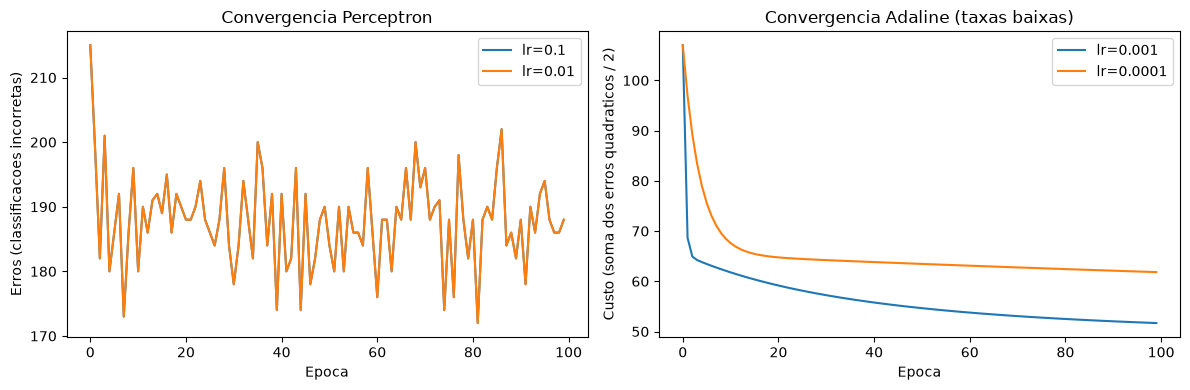

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

model_by_key = dict(models_trained)

for lr in [0.1, 0.01]:
    axes[0].plot(model_by_key[f'Perceptron lr={lr}'].errors, label=f'lr={lr}')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Erros (classificacoes incorretas)')
axes[0].set_title('Convergencia Perceptron')
axes[0].legend()

for lr in [0.001, 0.0001]:
    axes[1].plot(model_by_key[f'Adaline lr={lr}'].cost, label=f'lr={lr}')
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Custo (soma dos erros quadraticos / 2)')
axes[1].set_title('Convergencia Adaline (taxas baixas)')
axes[1].legend()

plt.tight_layout()
plt.show()


## ConclusÃµes

Resumo dos resultados (nIterations=100, divisÃ£o 80/20):

- **Perceptron lr=0.1** â†’ treino 0.7667 / teste **0.7597**
- **Perceptron lr=0.01** â†’ treino 0.7667 / teste 0.7597
- **Adaline lr=0.1** â†’ treino 0.6509 / teste 0.6558
- **Adaline lr=0.01** â†’ treino 0.6509 / teste 0.6558
- **Adaline lr=0.001** (extra) â†’ treino 0.3638 / teste 0.3506
- **Adaline lr=0.0001** (extra) â†’ treino 0.3491 / teste 0.3442

ObservaÃ§Ãµes:

1. **Taxas de aprendizado (0.1 e 0.01):** no Perceptron as duas taxas convergem para o mesmo modelo (~0.76 de acurÃ¡cia no teste). Os erros por Ã©poca oscilam entre ~170 e ~215 sem chegar a 0, pois a base diabetes nÃ£o Ã© linearmente separÃ¡vel. A taxa 0.1 apenas atinge o mesmo limite em menos Ã©pocas.

2. **Perceptron vs Adaline:** o Adaline **nÃ£o** melhorou o resultado. Com lr 0.1 e 0.01 o gradiente em lote (soma dos erros quadrÃ¡ticos) explodiu: o custo cresceu atÃ© infinito (overflow) porque as entradas estÃ£o normalizadas em [0,1] (mÃ©dia > 0) e essas taxas sÃ£o grandes demais. Com os pesos explodidos, o modelo passou a classificar praticamente tudo como a classe majoritÃ¡ria (~65% da base), resultando em ~0.65 de acurÃ¡cia.

3. **VerificaÃ§Ã£o extra (taxas baixas):** com lr 0.001 e 0.0001 o custo do Adaline decresce de forma estÃ¡vel (ele converge), confirmando que o modelo Ã© bem mais sensÃ­vel Ã  taxa de aprendizado que o Perceptron. PorÃ©m a acurÃ¡cia fica baixa (~0.35), pois a regressÃ£o linear por mÃ­nimos quadrados sobre rÃ³tulos 0/1 nÃ£o define uma fronteira adequada para este problema. O melhor resultado foi do **Perceptron com acurÃ¡cia de teste de 0.7597**.
